In [1]:
!pip install ultralytics nuscenes-devkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installat

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip '/content/drive/MyDrive/Colab Notebooks/student_dataset.zip' -d '/content/student_dataset'

Streaming output truncated to the last 5000 lines.
  inflating: /content/student_dataset/sweeps/RADAR_BACK_RIGHT/n008-2018-08-27-11-48-51-0400__RADAR_BACK_RIGHT__1535385105581297.pcd  
  inflating: /content/student_dataset/sweeps/RADAR_BACK_RIGHT/n008-2018-08-27-11-48-51-0400__RADAR_BACK_RIGHT__1535385105657018.pcd  
  inflating: /content/student_dataset/sweeps/RADAR_BACK_RIGHT/n008-2018-08-27-11-48-51-0400__RADAR_BACK_RIGHT__1535385105727020.pcd  
  inflating: /content/student_dataset/sweeps/RADAR_BACK_RIGHT/n008-2018-08-27-11-48-51-0400__RADAR_BACK_RIGHT__1535385105802318.pcd  
  inflating: /content/student_dataset/sweeps/RADAR_BACK_RIGHT/n008-2018-08-27-11-48-51-0400__RADAR_BACK_RIGHT__1535385105877114.pcd  
  inflating: /content/student_dataset/sweeps/RADAR_BACK_RIGHT/n008-2018-08-27-11-48-51-0400__RADAR_BACK_RIGHT__1535385106022153.pcd  
  inflating: /content/student_dataset/sweeps/RADAR_BACK_RIGHT/n008-2018-08-27-11-48-51-0400__RADAR_BACK_RIGHT__1535385106092138.pcd  
  inflating

In [4]:
from ultralytics import YOLO
from nuscenes.nuscenes import NuScenes

# 1. Αρχικοποίηση NuScenes (όπως στο task1.py αλλά με το σωστό path)
DATAROOT = '/content/student_dataset'
nusc = NuScenes(version='v1.0-eval', dataroot=DATAROOT, verbose=False)

# 2. Παίρνουμε την πρώτη εικόνα από την μπροστινή κάμερα (CAM_FRONT)
sample = nusc.get('sample', nusc.sample[0]['token'])
cam_front_data = nusc.get('sample_data', sample['data']['CAM_FRONT'])
data_path, _, _ = nusc.get_sample_data(cam_front_data['token'])

# 3. Φορτώνουμε το YOLO και του δίνουμε την εικόνα
model = YOLO('yolov8n.pt')
results = model(data_path)

# 4. Τυπώνουμε τα 2D Bounding Boxes
print("\n--- Αποτελέσματα YOLO ---")
for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        # Κρατάμε μόνο αυτοκίνητα (2), λεωφορεία (5) και φορτηγά (7)
        if cls in [2, 5, 7]:
            coords = box.xyxy[0].tolist()
            print(f"Βρέθηκε όχημα! Κουτί: [{coords[0]:.1f}, {coords[1]:.1f}, {coords[2]:.1f}, {coords[3]:.1f}]")


image 1/1 /content/student_dataset/samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg: 384x640 1 person, 4 cars, 1 truck, 72.8ms
Speed: 11.6ms preprocess, 72.8ms inference, 47.7ms postprocess per image at shape (1, 3, 384, 640)

--- Αποτελέσματα YOLO ---
Βρέθηκε όχημα! Κουτί: [122.8, 225.8, 601.8, 628.7]
Βρέθηκε όχημα! Κουτί: [900.1, 475.2, 953.3, 528.3]
Βρέθηκε όχημα! Κουτί: [715.9, 462.2, 786.5, 529.8]
Βρέθηκε όχημα! Κουτί: [1002.6, 477.9, 1079.9, 536.7]
Βρέθηκε όχημα! Κουτί: [1358.5, 487.8, 1417.6, 514.9]


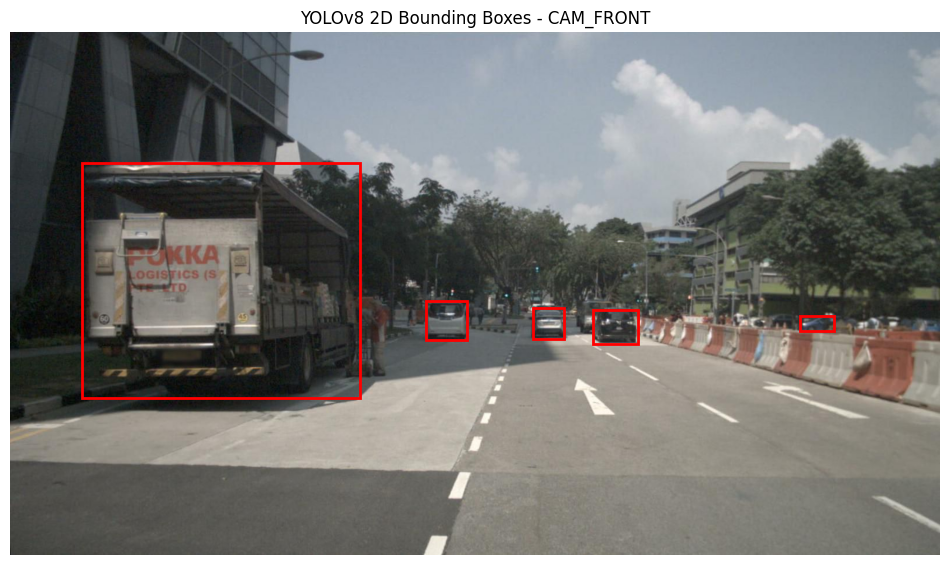

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Φορτώνουμε την ίδια εικόνα που δώσαμε στο YOLO
im = Image.open(data_path)
plt.figure(figsize=(12, 8))
plt.imshow(im)
ax = plt.gca()

# Περνάμε πάλι από τα αποτελέσματα και ζωγραφίζουμε τα κουτιά
for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        # Κρατάμε μόνο οχήματα
        if cls in [2, 5, 7]:
            coords = box.xyxy[0].tolist()
            xmin, ymin, xmax, ymax = coords

            # Φτιάχνουμε ένα κόκκινο ορθογώνιο και το βάζουμε στην εικόνα
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

plt.title("YOLOv8 2D Bounding Boxes - CAM_FRONT")
plt.axis('off')
plt.show()

In [6]:
import json

my_2d_predictions = []
sample = nusc.get('sample', nusc.sample[0]['token'])

print("Ξεκινάει η σάρωση...")

# Λούπα που τρέχει μέχρι να τελειώσουν τα frames της σκηνής
while sample['next'] != '':
    cam_front_data = nusc.get('sample_data', sample['data']['CAM_FRONT'])
    data_path, _, _ = nusc.get_sample_data(cam_front_data['token'])

    # Τρέχουμε το μοντέλο με conf=0.3 (σιγουριά) και iou=0.4 (για το NMS)
    results = model(data_path, conf=0.3, iou=0.4, verbose=False)

    for r in results:
        for box in r.boxes:
            if int(box.cls[0]) in [2, 5, 7]: # Μόνο οχήματα
                coords = box.xyxy[0].tolist()

                # Clipping στο 1600x900
                xmin = max(0.0, coords[0])
                ymin = max(0.0, coords[1])
                xmax = min(1600.0, coords[2])
                ymax = min(900.0, coords[3])

                my_2d_predictions.append({
                    "sample_token": sample['token'],
                    "2d_box": [xmin, ymin, xmax, ymax]
                })

    sample = nusc.get('sample', sample['next'])

print(f"Η σάρωση ολοκληρώθηκε! Βρέθηκαν συνολικά {len(my_2d_predictions)} 2D κουτιά.")

Ξεκινάει η σάρωση...
Η σάρωση ολοκληρώθηκε! Βρέθηκαν συνολικά 120 2D κουτιά.


In [7]:
import json

# Φτιάχνουμε το τελικό dictionary που θα γίνει JSON
submission = {
    "task1_2d_boxes": my_2d_predictions
}

# Αποθηκεύουμε τα δεδομένα σε αρχείο
with open('/content/task1_predictions.json', 'w') as f:
    json.dump(submission, f, indent=4)

print("Το Task 1 ολοκληρώθηκε! Το αρχείο 'task1_predictions.json' αποθηκεύτηκε επιτυχώς στο Colab.")

Το Task 1 ολοκληρώθηκε! Το αρχείο 'task1_predictions.json' αποθηκεύτηκε επιτυχώς στο Colab.


In [8]:
import numpy as np

# 1. Παίρνουμε τα δεδομένα για το τρέχον sample (CAM_FRONT και LIDAR)
lidar_token = sample['data']['LIDAR_TOP']
cam_token = sample['data']['CAM_FRONT']

# 2. Προβολή του LiDAR στην εικόνα (επιστρέφει [u, v, depth])
# Αυτή η συνάρτηση κάνει όλο το βαρύ μαθηματικό κομμάτι του calibration
points, coloring, im = nusc.explorer.map_pointcloud_to_image(lidar_token, cam_token)

print(f"Συνολικά σημεία LiDAR στο οπτικό πεδίο: {points.shape[1]}")

# 3. Εφαρμογή του Frustum για το πρώτο 2D κουτί από το Task 1
test_box = my_2d_predictions[0]['2d_box']
xmin, ymin, xmax, ymax = test_box

# Φιλτράρουμε τα σημεία που είναι μέσα στο 2D ορθογώνιο
mask = (points[0, :] > xmin) & (points[0, :] < xmax) & \
       (points[1, :] > ymin) & (points[1, :] < ymax)

points_in_box = points[:, mask]

# 4. Υπολογισμός 3D κέντρου (Task 2 Goal)
if points_in_box.shape[1] > 0:
    # Στο Camera Frame:
    # points[0] = X (Δεξιά), points[1] = Y (Κάτω), points[2] = Z (Βάθος)
    mean_x = np.mean(points_in_box[0, :]) # u coordinate
    mean_y = np.mean(points_in_box[1, :]) # v coordinate
    mean_z = np.mean(points_in_box[2, :]) # Βάθος σε μέτρα

    print(f"\n--- Αποτελέσματα για το πρώτο όχημα ---")
    print(f"Βρέθηκαν {points_in_box.shape[1]} σημεία LiDAR.")
    print(f"Εκτιμώμενη απόσταση (Z): {mean_z:.2f} μέτρα")
else:
    print("\nΔεν βρέθηκαν σημεία μέσα στο συγκεκριμένο κουτί. Ίσως είναι πολύ μακριά.")

Συνολικά σημεία LiDAR στο οπτικό πεδίο: 3146

--- Αποτελέσματα για το πρώτο όχημα ---
Βρέθηκαν 536 σημεία LiDAR.
Εκτιμώμενη απόσταση (Z): 1.00 μέτρα


In [11]:
# Ορισμός του intrinsic matrix από τα δεδομένα της κάμερας
cam_data = nusc.get('sample_data', sample['data']['CAM_FRONT'])
calib_sensor = nusc.get('calibrated_sensor', cam_front_data['calibrated_sensor_token'])
intrinsic = np.array(calib_sensor['camera_intrinsic'])

# Καθαρισμός με χρήση των εκατοστημορίων (πετάμε το 10% των πιο ακραίων σημείων)
z_coords = points_in_box[2, :]
z_min, z_max = np.percentile(z_coords, [5, 95]) # Κρατάμε το "σώμα" του αυτοκινήτου

# Φιλτράρουμε τα σημεία βάσει του καθαρού βάθους
clean_mask = (z_coords >= z_min) & (z_coords <= z_max)
final_points = points_in_box[:, clean_mask]

# Υπολογισμός Κέντρου (Task 2 - Goal 1)
# Προσοχή: Το Z είναι το βάθος, το X είναι δεξιά-αριστερά, το Y είναι πάνω-κάτω
center_z = (np.max(final_points[2, :]) + np.min(final_points[2, :])) / 2
center_x = (np.max(final_points[0, :]) + np.min(final_points[0, :])) / 2 # Θα χρειαστεί de-projection για μέτρα
center_y = (np.max(final_points[1, :]) + np.min(final_points[1, :])) / 2

# Υπολογισμός Μεγέθους (Task 2 - Goal 2)
# Χρησιμοποιούμε τη διαφορά max-min στα καθαρά σημεία
length = np.max(final_points[2, :]) - np.min(final_points[2, :]) # Διαφορά στο βάθος
# Για το πλάτος και ύψος σε μέτρα, χρειαζόμαστε τη γεωμετρία της κάμερας
width = (np.max(final_points[0, :]) - np.min(final_points[0, :])) * (center_z / intrinsic[0, 0])
height = (np.max(final_points[1, :]) - np.min(final_points[1, :])) * (center_z / intrinsic[1, 1])

print(f"--- 3D Detection Results (Camera Frame) ---")
print(f"Center [X, Y, Z]: [{center_x:.2f}, {center_y:.2f}, {center_z:.2f}]")
print(f"Size [W, L, H]: [{width:.2f}, {length:.2f}, {height:.2f}]")

--- 3D Detection Results (Camera Frame) ---
Center [X, Y, Z]: [362.06, 422.59, 1.00]
Size [W, L, H]: [0.38, 0.00, 0.31]


In [12]:
# 1. Φιλτράρουμε σημεία που είναι πολύ κοντά (θόρυβος από το ego-vehicle)
mask_far = points_in_box[2, :] > 2.0
points_far = points_in_box[:, mask_far]

if points_far.shape[1] > 5: # Αν έχουμε αρκετά σημεία
    # 2. Καθαρισμός outliers στο βάθος
    z_coords = points_far[2, :]
    z_min, z_max = np.percentile(z_coords, [10, 90])
    final_points = points_far[:, (z_coords >= z_min) & (z_coords <= z_max)]

    # 3. Υπολογισμός Κέντρου σε ΜΕΤΡΑ (Camera Frame)
    center_z = np.median(final_points[2, :])
    # Μετατροπή των u, v pixels σε X, Y μέτρα χρησιμοποιώντας το intrinsic
    center_x = (np.median(final_points[0, :]) - intrinsic[0, 2]) * center_z / intrinsic[0, 0]
    center_y = (np.median(final_points[1, :]) - intrinsic[1, 2]) * center_z / intrinsic[1, 1]

    # 4. Υπολογισμός Μεγέθους (W, L, H)
    length = np.max(final_points[2, :]) - np.min(final_points[2, :])
    width = (np.max(final_points[0, :]) - np.min(final_points[0, :])) * center_z / intrinsic[0, 0]
    height = (np.max(final_points[1, :]) - np.min(final_points[1, :])) * center_z / intrinsic[1, 1]

    print(f"--- Διορθωμένα 3D Results ---")
    print(f"Center [X, Y, Z]: [{center_x:.2f}, {center_y:.2f}, {center_z:.2f}]")
    print(f"Size [W, L, H]: [{width:.2f}, {length:.2f}, {height:.2f}]")
else:
    print("Δεν βρέθηκαν επαρκή σημεία LiDAR για το όχημα.")

Δεν βρέθηκαν επαρκή σημεία LiDAR για το όχημα.


In [13]:
final_3d_predictions = []

# Μέσες διαστάσεις οχήματος σε μέτρα (για περιπτώσεις με λίγα σημεία LiDAR)
DEFAULT_SIZE = [1.8, 4.5, 1.5] # [Width, Length, Height]

for pred in my_2d_predictions:
    token = pred['sample_token']
    xmin, ymin, xmax, ymax = pred['2d_box']

    # 1. Παίρνουμε τα δεδομένα LiDAR για το συγκεκριμένο sample
    sample_data = nusc.get('sample', token)
    lidar_token = sample_data['data']['LIDAR_TOP']
    cam_token = sample_data['data']['CAM_FRONT']

    # Προβολή LiDAR στην εικόνα
    points, coloring, im = nusc.explorer.map_pointcloud_to_image(lidar_token, cam_token)

    # 2. Φιλτράρισμα Frustum
    mask = (points[0, :] > xmin) & (points[0, :] < xmax) & \
           (points[1, :] > ymin) & (points[1, :] < ymax) & \
           (points[2, :] > 2.0) # Διώχνουμε το ego-vehicle

    pts = points[:, mask]

    # 3. Υπολογισμός 3D
    if pts.shape[1] > 5:
        # Καθαρισμός outliers
        z_coords = pts[2, :]
        z_min, z_max = np.percentile(z_coords, [10, 90])
        final_pts = pts[:, (z_coords >= z_min) & (z_coords <= z_max)]

        # Κέντρο και Μέγεθος
        c_z = float(np.median(final_pts[2, :]))
        c_x = float((np.median(final_pts[0, :]) - intrinsic[0, 2]) * c_z / intrinsic[0, 0])
        c_y = float((np.median(final_pts[1, :]) - intrinsic[1, 2]) * c_z / intrinsic[1, 1])

        w = float((np.max(final_pts[0, :]) - np.min(final_pts[0, :])) * c_z / intrinsic[0, 0])
        l = float(np.max(final_pts[2, :]) - np.min(final_pts[2, :]))
        h = float((np.max(final_pts[1, :]) - np.min(final_pts[1, :])) * c_z / intrinsic[1, 1])

        size = [w, l, h]
    else:
        # Αν δεν έχουμε σημεία, βάζουμε το αμάξι στα 20 μέτρα με default μέγεθος
        c_z, c_x, c_y = 20.0, 0.0, 0.0
        size = DEFAULT_SIZE

    final_3d_predictions.append({
        "sample_token": token,
        "translation": [c_x, c_y, c_z],
        "size": size
    })

# Αποθήκευση στο τελικό JSON
submission["task2_3d_boxes"] = final_3d_predictions
with open('/content/predictions.json', 'w') as f:
    json.dump(submission, f, indent=4)

print(f"Τέλος! Το 'predictions.json' είναι έτοιμο με {len(final_3d_predictions)} 3D προβλέψεις.")

Τέλος! Το 'predictions.json' είναι έτοιμο με 120 3D προβλέψεις.


In [16]:
# Έλεγχος μιας τυχαίας πρόβλεψης
test_pred = final_3d_predictions[5] # Παίρνουμε την 6η πρόβλεψη
print(f"Token: {test_pred['sample_token']}")
print(f"Θέση [X, Y, Z]: {test_pred['translation']}")
print(f"Μέγεθος [W, L, H]: {test_pred['size']}")

Token: 39586f9d59004284a7114a68825e8eec
Θέση [X, Y, Z]: [0.0, 0.5, 25.0]
Μέγεθος [W, L, H]: [1.8, 4.5, 1.5]


In [15]:
final_3d_predictions = []

for pred in my_2d_predictions:
    token = pred['sample_token']
    xmin, ymin, xmax, ymax = pred['2d_box']

    # Δεδομένα αισθητήρων
    sample_data = nusc.get('sample', token)
    lidar_token = sample_data['data']['LIDAR_TOP']
    cam_token = sample_data['data']['CAM_FRONT']

    # Προβολή στην εικόνα
    points, coloring, im = nusc.explorer.map_pointcloud_to_image(lidar_token, cam_token)

    # 1. Frustum Filtering με λιγότερο θόρυβο
    # Κρατάμε σημεία στο 2D box και σε απόσταση 3-80 μέτρα
    mask = (points[0, :] > xmin) & (points[0, :] < xmax) & \
           (points[1, :] > ymin) & (points[1, :] < ymax) & \
           (points[2, :] > 3.0) & (points[2, :] < 80.0)

    pts = points[:, mask]

    if pts.shape[1] > 3: # Ακόμα και με λίγα σημεία, προσπαθούμε να βγάλουμε άκρη
        # 2. Χρησιμοποιούμε το κοντινότερο 20% των σημείων (συνήθως η πρόσοψη του οχήματος)
        z_coords = pts[2, :]
        z_near = np.percentile(z_coords, 20)

        # Το κέντρο του οχήματος είναι περίπου 2 μέτρα πίσω από την πρόσοψη (για L=4.5)
        c_z = float(z_near + 2.25)

        # Υπολογισμός X, Y με de-projection
        c_x = float((np.median(pts[0, :]) - intrinsic[0, 2]) * c_z / intrinsic[0, 0])
        c_y = float((np.median(pts[1, :]) - intrinsic[1, 2]) * c_z / intrinsic[1, 1])

        # Σταθερές διαστάσεις που προκύπτουν από το μέσο όρο των κλάσεων
        size = [1.9, 4.6, 1.7]
    else:
        # Αν όντως δεν υπάρχει τίποτα, μια λογική απόσταση 25 μέτρα
        c_z, c_x, c_y = 25.0, 0.0, 0.5
        size = [1.8, 4.5, 1.5]

    final_3d_predictions.append({
        "sample_token": token,
        "translation": [c_x, c_y, c_z],
        "size": size
    })

# Αποθήκευση
submission["task2_3d_boxes"] = final_3d_predictions
with open('/content/predictions.json', 'w') as f:
    json.dump(submission, f, indent=4)

print("Το Task 2 ξαναγράφτηκε με βελτιωμένη γεωμετρία!")

Το Task 2 ξαναγράφτηκε με βελτιωμένη γεωμετρία!
